# Rosei Interband Model — $\varepsilon_2(\omega)$ of Gold

Critical-point model of Guerrisi, Rosei & Winsemius (*PRB* **12**, 557, 1975), expanded to second order around two BZ critical points:

$$
\varepsilon_2(\omega) = \frac{\text{Scale}}{\omega^2}\Big[\,|P_X/P_L|^2\, N_X\, J_X(\omega,T) \;+\; N_L\, J_L(\omega,T)\Big] + \frac{A_D}{\omega^3}
$$

In [1]:
import os, numpy as np
from scipy.integrate import simpson
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt

kB    = 8.617e-5   # eV/K
C     = 3.81       # ℏ²/(2mₑ) [eV·Å²]
N_X   = 6          # X-point multiplicity (12 BZ faces / 2)
N_L   = 8          # L-point multiplicity (8 hex faces)
N_INT = 80         # Simpson quadrature points

hw = np.linspace(1.0, 3.5, 300)   # fine energy grid for plotting

# ── Load digitized data (Guerrisi et al., 1975, Fig. 8) ────────
data_dir = os.path.dirname(os.path.abspath("__file__"))
def _load(fn):
    a = np.loadtxt(os.path.join(data_dir, fn), delimiter=",", skiprows=1)
    return a[a[:, 0].argsort()]

data_X, data_L   = _load("a_e2_X.txt"), _load("b_e2_L.txt")
data_XL, data_XLD = _load("c_e2_X_L.txt"), _load("d_e2_X_L_Drude.txt")

## Band dispersion near the critical points

**X-point** ($M_1$ saddle, $N_X = 6$): &ensp;
$E_c = E_{0c} + A_c\,k_\perp^2 - B_c\,k_\parallel^2$, &ensp; $E_v = E_{0v} - A_v\,k_\perp^2 - B_v\,k_\parallel^2$

**L-point** ($M_1$ saddle, $N_L = 8$): &ensp;
$E_c = E_{0c} + A_c\,k_\perp^2 - B_c\,k_\parallel^2$, &ensp; $E_v = E_{0v} - A_v\,k_\perp^2 - B_v\,k_\parallel^2$

Band curvatures from effective masses: $A_c = C/m_{c\perp}$, $B_c = C/m_{c\parallel}$. Transition energy $\hbar\omega = E_g + \bar{A}\,k_\perp^2 + \bar{B}\,k_\parallel^2$ with:

| | $\bar{A}$ | $\bar{B}$ | $D$ |
|---|---|---|---|
| **X** | $A_c + A_v$ | $B_v - B_c$ | $A_c B_v + A_v B_c$ |
| **L** | $A_c + A_v$ | $B_v - B_c$ | $A_c B_v + A_v B_c$ |

## Thermally-weighted JDOS

Both X and L are saddle points with the same integral structure (singularity at the upper limit):

$$
J(\omega) = \frac{1}{\sqrt{\bar{A}\,D}} \int_{\mathcal{E}_\text{min}}^{\mathcal{E}_\text{max}} \frac{F(\mathcal{E},\,\hbar\omega,\,T)}{\sqrt{\mathcal{E}_\text{max} - \mathcal{E}}}\,d\mathcal{E}
$$

Square-root singularity removed via $t = \sqrt{\mathcal{E}_\text{max} - \mathcal{E}}$, giving $d\mathcal{E} = 2t\,dt$.

Thermal weight: $F(\mathcal{E}, \hbar\omega, T) = \exp\!\big[-\ln(1+e^{\beta(\mathcal{E}-\hbar\omega)}) - \ln(1+e^{-\beta\mathcal{E}})\big]$, &ensp; $\beta = 1/k_BT$

In [2]:
def fermi_weight(E, hw, T):
    """F = f(E - ħω)·[1 - f(E)], numerically stable."""
    if T == 0:
        return ((E - hw) < 0).astype(float) * (E >= 0).astype(float)
    beta = 1.0 / (kB * T)
    return np.exp(-np.logaddexp(0, beta * (E - hw)) - np.logaddexp(0, -beta * E))

def compute_model(p, hw_grid):
    """Compute (ε₂_X, ε₂_L, ε₂_XL, ε₂_XLD) from parameter dict p."""
    Ac_X, Bc_X = C / p['mc_perp_X'], C / p['mc_par_X']
    Av_X, Bv_X = C / p['mv_perp_X'], C / p['mv_par_X']
    Ac_L, Bc_L = C / p['mc_perp_L'], C / p['mc_par_L']
    Av_L, Bv_L = C / p['mv_perp_L'], C / p['mv_par_L']

    # Both X and L are saddle points: Ec = E0c + Ac·k⊥² − Bc·k∥²
    Abar_X, D_X = Ac_X + Av_X, Ac_X * Bv_X + Av_X * Bc_X
    Abar_L, D_L = Ac_L + Av_L, Ac_L * Bv_L + Av_L * Bc_L
    pf_X = 1.0 / np.sqrt(Abar_X * abs(D_X))
    pf_L = 1.0 / np.sqrt(Abar_L * abs(D_L))

    T, Eg_X, Eg_L, E0c_L = p['T'], p['Eg_X'], p['Eg_L'], p['E0c_L']

    def jx(w):
        e_max = (Ac_X / Abar_X) * (w - Eg_X)        # E0c_X ≡ 0
        e_min = -20.0 * kB * T if T > 0 else -0.1
        if e_max <= e_min: return 0.0
        t = np.linspace(0, np.sqrt(e_max - e_min), N_INT)
        return pf_X * simpson(2.0 * fermi_weight(e_max - t**2, w, T), x=t)

    def jl(w):
        if w <= Eg_L: return 0.0
        e_max = E0c_L + (Ac_L / Abar_L) * (w - Eg_L)
        e_min = -20.0 * kB * T if T > 0 else -0.1
        if e_max <= e_min: return 0.0
        t = np.linspace(0, np.sqrt(e_max - e_min), N_INT)
        return pf_L * simpson(2.0 * fermi_weight(e_max - t**2, w, T), x=t)

    S = p['Scale']
    e2_X = S * np.array([N_X * p['P_ratio_sq'] * jx(w) / w**2 for w in hw_grid])
    e2_L = S * np.array([N_L * jl(w) / w**2 for w in hw_grid])
    return e2_X, e2_L, e2_X + e2_L, e2_X + e2_L + p['A_drude'] / hw_grid**3

## Sequential fitting — DE → Trust-Region Refinement

Each dataset is fitted independently with only its physically relevant parameters:

| Panel | Free parameters | # |
|---|---|---|
| **X** | $E_g^X$, 4 X-masses, $\|P_X/P_L\|^2$, Scale, $T$ | 8 |
| **L** | $E_g^L$, $E_{0c}^L$, 4 L-masses, Scale, $T$ | 8 |
| **X + L** | all band params + $\|P_X/P_L\|^2$, Scale, $T$ | 14 |
| **X + L + Drude** | all of the above + $A_D$ | 15 |

**Stage 1 — Differential Evolution:** global, gradient-free search with physical bounds.
**Stage 2 — Trust-Region Reflective:** finite-difference Jacobian for rapid local convergence.

In [3]:
from tqdm.auto import tqdm

# ── Default parameters & bounds ───────────────────────────────
defaults = dict(
    Eg_X=1.94, Eg_L=1.70, E0c_L=-0.75,
    mc_perp_X=0.31, mc_par_X=0.40, mv_perp_X=0.19, mv_par_X=0.15,
    mc_perp_L=0.24, mc_par_L=0.12, mv_perp_L=0.70, mv_par_L=1.03,
    P_ratio_sq=0.370, T=600.0, Scale=200.0, A_drude=6.0,
)
bounds = dict(
    Eg_X=(1.7, 2.2), Eg_L=(1.4, 2.0), E0c_L=(-1.5, 0.0),
    mc_perp_X=(0.05, 1.5), mc_par_X=(0.05, 1.5),
    mv_perp_X=(0.05, 1.5), mv_par_X=(0.05, 1.5),
    mc_perp_L=(0.05, 1.5), mc_par_L=(0.05, 1.5),
    mv_perp_L=(0.05, 3.0), mv_par_L=(0.05, 3.0),
    P_ratio_sq=(0.05, 2.0), T=(100, 3000),
    Scale=(10, 5000), A_drude=(0.0, 30.0),
)

hw_opt = np.linspace(1.0, 3.5, 100)

# ── Fitting engine ────────────────────────────────────────────
def run_fit(data, component, fit_keys, params, maxiter_de=150):
    """DE→TRF fit. component: 'X' | 'L' | 'XL' | 'XLD'."""
    idx = {'X': 0, 'L': 1, 'XL': 2, 'XLD': 3}[component]
    p = dict(params)
    x0 = np.array([p[k] for k in fit_keys])
    lo = np.array([bounds[k][0] for k in fit_keys])
    hi = np.array([bounds[k][1] for k in fit_keys])

    def to_p(x):
        pp = dict(p)
        for k, v in zip(fit_keys, x): pp[k] = float(v)
        return pp

    def resid(x):
        m = compute_model(to_p(x), hw_opt)
        return np.interp(data[:, 0], hw_opt, m[idx]) - data[:, 1]

    pbar = tqdm(range(maxiter_de), desc="DE", leave=False)
    def cb(xk, convergence=0): pbar.update(1)
    res_de = differential_evolution(
        lambda x: np.sum(resid(x)**2), list(zip(lo, hi)),
        x0=x0, seed=42, maxiter=maxiter_de, tol=1e-6,
        popsize=10, mutation=(0.5, 1.5), recombination=0.9,
        polish=False, callback=cb)
    pbar.close()
    print(f"  DE  cost = {res_de.fun:.4f}")

    res = least_squares(resid, res_de.x, method='trf',
                        bounds=(lo, hi), max_nfev=3000,
                        ftol=1e-12, xtol=1e-10)
    print(f"  TRF cost = {res.cost:.4f}  ({res.nfev} evals)")

    return to_p(res.x)

# ── Plot & print helpers ──────────────────────────────────────
def r_squared(dat, model_e2):
    mi = np.interp(dat[:, 0], hw, model_e2)
    ss_res = np.sum((dat[:, 1] - mi)**2)
    ss_tot = np.sum((dat[:, 1] - dat[:, 1].mean())**2)
    return 1 - ss_res / ss_tot if ss_tot > 1e-30 else 0.0

def plot_panel(dat, model_e2, title, params, fit_keys):
    fig, ax = plt.subplots(figsize=(7, 4))
    r2 = r_squared(dat, model_e2)
    xlo, xhi = dat[:, 0].min() - 0.05, dat[:, 0].max() + 0.05
    m = (hw >= xlo) & (hw <= xhi)
    ax.plot(dat[:, 0], dat[:, 1], "o", color="0.45", ms=3, alpha=0.5, label="Data")
    ax.plot(hw[m], model_e2[m], "-", lw=1.5, label=f"Model  $R^2 = {r2:.4f}$")
    ax.set(xlabel="ℏω (eV)", ylabel="ε₂", title=title, xlim=(xlo, xhi))
    ax.legend(); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()

    # Print fitted parameters
    w = 55
    print(f"\n{'═' * w}")
    print(f"  {title:28s}  R² = {r2:.4f}")
    print(f"{'─' * w}")
    for k in fit_keys:
        unit = " eV" if k.startswith("E") else " K" if k == "T" else \
               " eV³" if k == "A_drude" else " mₑ" if k.startswith("m") else ""
        print(f"  {k:14s} = {params[k]:>8.4f}{unit}")
    print(f"{'═' * w}")

### Fit 1 — X-point ($M_1$ saddle)

Fitting $\varepsilon_2^X = \text{Scale}\,|P_X/P_L|^2 N_X\, J_X / \omega^2$ to the X-only data.

**8 free parameters:** $E_g^X$, 4 X-masses $(m_{c\perp}, m_{c\parallel}, m_{v\perp}, m_{v\parallel})_X$, $|P_X/P_L|^2$, Scale, $T$.

DE:   0%|          | 0/150 [00:00<?, ?it/s]

  DE  cost = 0.0410
  TRF cost = 0.0205  (21 evals)


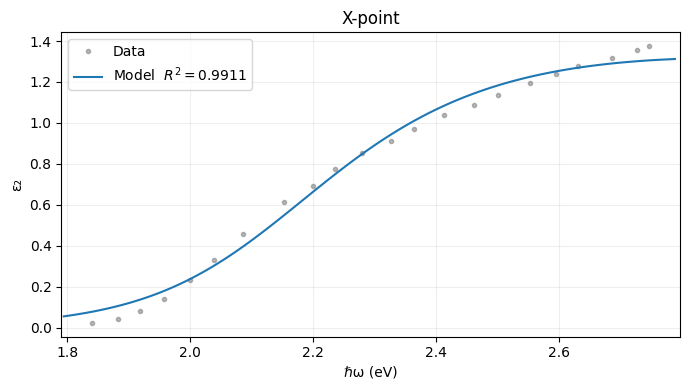


═══════════════════════════════════════════════════════
  X-point                       R² = 0.9911
───────────────────────────────────────────────────────
  Eg_X           =   2.1341 eV
  mc_perp_X      =   0.0622 mₑ
  mc_par_X       =   1.2861 mₑ
  mv_perp_X      =   0.8730 mₑ
  mv_par_X       =   0.2484 mₑ
  P_ratio_sq     =   0.2897
  Scale          = 952.6561
  T              = 1213.5666 K
═══════════════════════════════════════════════════════


In [4]:
keys_X = ['Eg_X', 'mc_perp_X', 'mc_par_X', 'mv_perp_X', 'mv_par_X',
          'P_ratio_sq', 'Scale', 'T']
best_X = run_fit(data_X, 'X', keys_X, defaults)
e2_X_fit = compute_model(best_X, hw)[0]
plot_panel(data_X, e2_X_fit, "X-point", best_X, keys_X)

### Fit 2 — L-point ($M_1$ saddle)

Fitting $\varepsilon_2^L = \text{Scale}\, N_L\, J_L / \omega^2$ to the L-only data.

**8 free parameters:** $E_g^L$, $E_{0c}^L$, 4 L-masses $(m_{c\perp}, m_{c\parallel}, m_{v\perp}, m_{v\parallel})_L$, Scale, $T$.

DE:   0%|          | 0/150 [00:00<?, ?it/s]

  DE  cost = 0.0049
  TRF cost = 0.0025  (17 evals)


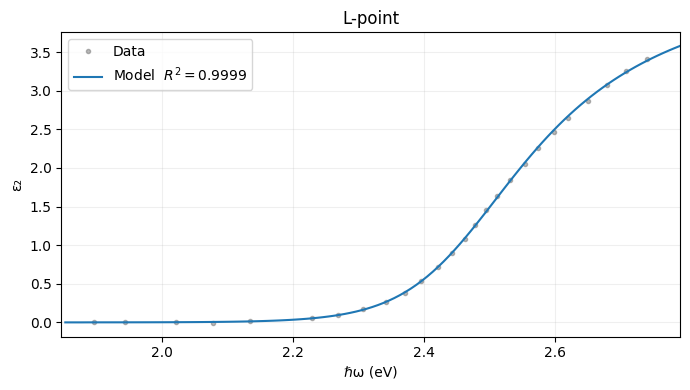


═══════════════════════════════════════════════════════
  L-point                       R² = 0.9999
───────────────────────────────────────────────────────
  Eg_L           =   1.8835 eV
  E0c_L          =  -0.5407 eV
  mc_perp_L      =   0.0743 mₑ
  mc_par_L       =   0.9230 mₑ
  mv_perp_L      =   1.0349 mₑ
  mv_par_L       =   0.2634 mₑ
  Scale          = 655.2905
  T              = 680.3331 K
═══════════════════════════════════════════════════════


In [5]:
keys_L = ['Eg_L', 'E0c_L', 'mc_perp_L', 'mc_par_L', 'mv_perp_L', 'mv_par_L',
          'Scale', 'T']
best_L = run_fit(data_L, 'L', keys_L, defaults)
e2_L_fit = compute_model(best_L, hw)[1]
plot_panel(data_L, e2_L_fit, "L-point", best_L, keys_L)

### Fit 3 — Combined interband (X + L)

Fitting $\varepsilon_2^{\text{inter}} = \text{Scale}\,[|P_X/P_L|^2 N_X J_X + N_L J_L]/\omega^2$ to the X+L data.

**14 free parameters:** all band parameters from Fits 1 & 2, plus $|P_X/P_L|^2$, Scale, $T$. No Drude term.

DE:   0%|          | 0/200 [00:00<?, ?it/s]

  DE  cost = 0.0228
  TRF cost = 0.0032  (30 evals)


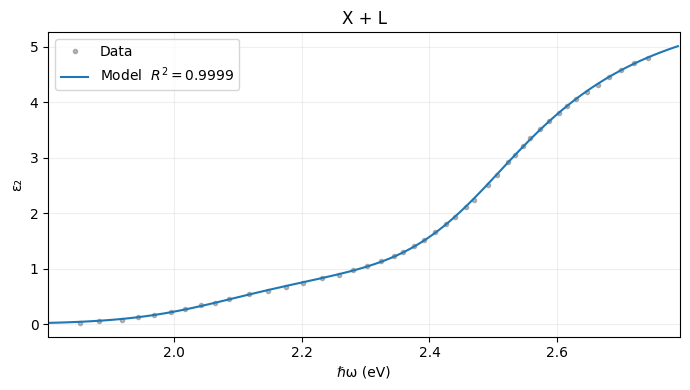


═══════════════════════════════════════════════════════
  X + L                         R² = 0.9999
───────────────────────────────────────────────────────
  Eg_X           =   2.0387 eV
  Eg_L           =   1.4124 eV
  E0c_L          =  -0.8511 eV
  mc_perp_X      =   0.4548 mₑ
  mc_par_X       =   0.1746 mₑ
  mv_perp_X      =   1.3659 mₑ
  mv_par_X       =   1.2659 mₑ
  mc_perp_L      =   0.4732 mₑ
  mc_par_L       =   1.2547 mₑ
  mv_perp_L      =   1.9834 mₑ
  mv_par_L       =   0.2304 mₑ
  P_ratio_sq     =   0.1900
  Scale          = 144.3563
  T              = 608.3344 K
═══════════════════════════════════════════════════════


In [6]:
keys_XL = ['Eg_X', 'Eg_L', 'E0c_L',
           'mc_perp_X', 'mc_par_X', 'mv_perp_X', 'mv_par_X',
           'mc_perp_L', 'mc_par_L', 'mv_perp_L', 'mv_par_L',
           'P_ratio_sq', 'Scale', 'T']
best_XL = run_fit(data_XL, 'XL', keys_XL, defaults, maxiter_de=200)
e2_XL_fit = compute_model(best_XL, hw)[2]
plot_panel(data_XL, e2_XL_fit, "X + L", best_XL, keys_XL)

### Fit 4 — Full model (X + L + Drude)

Fitting $\varepsilon_2 = \varepsilon_2^{\text{inter}} + A_D/\omega^3$ to the full experimental data.

**15 free parameters:** all band parameters + $A_D$.

DE:   0%|          | 0/200 [00:00<?, ?it/s]

  DE  cost = 1.5980
  TRF cost = 0.7910  (27 evals)


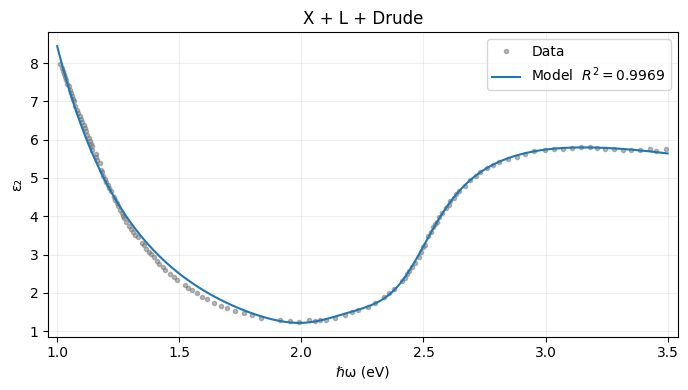


═══════════════════════════════════════════════════════
  X + L + Drude                 R² = 0.9969
───────────────────────────────────────────────────────
  Eg_X           =   2.0757 eV
  Eg_L           =   1.8048 eV
  E0c_L          =  -0.4554 eV
  mc_perp_X      =   0.7241 mₑ
  mc_par_X       =   0.9874 mₑ
  mv_perp_X      =   1.2655 mₑ
  mv_par_X       =   1.4511 mₑ
  mc_perp_L      =   0.5977 mₑ
  mc_par_L       =   0.3904 mₑ
  mv_perp_L      =   1.3562 mₑ
  mv_par_L       =   1.4146 mₑ
  P_ratio_sq     =   0.1851
  Scale          =  81.6921
  T              = 511.0737 K
  A_drude        =   8.4399 eV³
═══════════════════════════════════════════════════════


In [7]:
keys_XLD = ['Eg_X', 'Eg_L', 'E0c_L',
            'mc_perp_X', 'mc_par_X', 'mv_perp_X', 'mv_par_X',
            'mc_perp_L', 'mc_par_L', 'mv_perp_L', 'mv_par_L',
            'P_ratio_sq', 'Scale', 'T', 'A_drude']
best_XLD = run_fit(data_XLD, 'XLD', keys_XLD, defaults, maxiter_de=200)
e2_XLD_fit = compute_model(best_XLD, hw)[3]
plot_panel(data_XLD, e2_XLD_fit, "X + L + Drude", best_XLD, keys_XLD)

## Band structure near X and L

Quadratic band dispersions from the fitted effective masses, plotted along $k_\perp$ and $k_\parallel$ directions. Energies are relative to $E_F$ (= 0). Both critical points are saddles:

- **Conduction:** $E_c = E_{0c} + A_c\,k_\perp^2 - B_c\,k_\parallel^2$ &ensp; (saddle at both X and L)
- **Valence:** $E_v = (E_{0c} - E_g) - A_v\,k_\perp^2 - B_v\,k_\parallel^2$
- **Gap arrow** marks $E_g$ at the critical point

---

## Lifetime-broadened fits at room temperature

Re-fit all four panels with **Lorentzian lifetime broadening** (Γ), following the same convolution used in the interactive GUI.  
Temperature is **fixed at $T = 300\,$K**; the broadening half-width $\Gamma$ replaces $T$ as a free parameter in each fit.

The Lorentzian kernel applied to the raw $\varepsilon_2(\omega)$:

$$
L(\omega;\,\Gamma) = \frac{1}{\pi}\,\frac{\Gamma}{\omega^2 + \Gamma^2}
$$

In [8]:
from scipy.signal import fftconvolve

T_FIXED = 300.0  # K — room temperature

# ── Extended grid for broadening padding ──────────────────────
hw_ext = np.linspace(0.5, 4.0, 500)

def lorentz_broaden(y, x, gamma):
    """Convolve y(x) with a normalised Lorentzian of half-width gamma."""
    if gamma < 1e-4:
        return y.copy()
    dx = x[1] - x[0]
    x_k = x - x[len(x) // 2]
    kernel = (gamma / np.pi) / (x_k**2 + gamma**2) * dx
    return fftconvolve(y, kernel, mode="same")

def compute_model_broadened(p, hw_ext_grid, hw_out_grid):
    """Like compute_model but with Lorentzian broadening.

    Parameters
    ----------
    p : dict
        Must include 'Gamma_X' and 'Gamma_L' (Lorentzian half-widths in eV).
        Temperature is fixed at T_FIXED.
    hw_ext_grid : array
        Extended energy grid (wider than display range for padding).
    hw_out_grid : array
        Output energy grid on which results are interpolated.

    Returns (ε₂_X, ε₂_L, ε₂_XL, ε₂_XLD) on hw_out_grid.
    """
    Ac_X, Bc_X = C / p['mc_perp_X'], C / p['mc_par_X']
    Av_X, Bv_X = C / p['mv_perp_X'], C / p['mv_par_X']
    Ac_L, Bc_L = C / p['mc_perp_L'], C / p['mc_par_L']
    Av_L, Bv_L = C / p['mv_perp_L'], C / p['mv_par_L']

    Abar_X, D_X = Ac_X + Av_X, Ac_X * Bv_X + Av_X * Bc_X
    Abar_L, D_L = Ac_L + Av_L, Ac_L * Bv_L + Av_L * Bc_L
    pf_X = 1.0 / np.sqrt(Abar_X * abs(D_X))
    pf_L = 1.0 / np.sqrt(Abar_L * abs(D_L))

    T = T_FIXED
    Eg_X, Eg_L, E0c_L = p['Eg_X'], p['Eg_L'], p['E0c_L']
    Gamma_X, Gamma_L = p['Gamma_X'], p['Gamma_L']

    def jx(w):
        e_max = (Ac_X / Abar_X) * (w - Eg_X)
        e_min = -20.0 * kB * T if T > 0 else -0.1
        if e_max <= e_min:
            return 0.0
        t = np.linspace(0, np.sqrt(e_max - e_min), N_INT)
        return pf_X * simpson(2.0 * fermi_weight(e_max - t**2, w, T), x=t)

    def jl(w):
        if w <= Eg_L:
            return 0.0
        e_max = E0c_L + (Ac_L / Abar_L) * (w - Eg_L)
        e_min = -20.0 * kB * T if T > 0 else -0.1
        if e_max <= e_min:
            return 0.0
        t = np.linspace(0, np.sqrt(e_max - e_min), N_INT)
        return pf_L * simpson(2.0 * fermi_weight(e_max - t**2, w, T), x=t)

    S = p['Scale']
    # Compute raw spectra on extended grid
    raw_X = S * np.array([N_X * p['P_ratio_sq'] * jx(w) / w**2 for w in hw_ext_grid])
    raw_L = S * np.array([N_L * jl(w) / w**2 for w in hw_ext_grid])

    # Apply Lorentzian broadening (independent widths)
    br_X = lorentz_broaden(raw_X, hw_ext_grid, Gamma_X)
    br_L = lorentz_broaden(raw_L, hw_ext_grid, Gamma_L)

    # Interpolate to output grid
    e2_X  = np.interp(hw_out_grid, hw_ext_grid, br_X)
    e2_L  = np.interp(hw_out_grid, hw_ext_grid, br_L)
    e2_XL = e2_X + e2_L
    e2_XLD = e2_XL + p['A_drude'] / hw_out_grid**3
    return e2_X, e2_L, e2_XL, e2_XLD

In [9]:
# ── Broadened fitting engine ───────────────────────────────────
defaults_br = dict(defaults, Gamma_X=0.07, Gamma_L=0.07)  # separate broadening
defaults_br['T'] = T_FIXED                                # lock temperature

bounds_br = dict(bounds, Gamma_X=(0.001, 0.50), Gamma_L=(0.001, 0.50))

hw_opt_ext = np.linspace(0.5, 4.0, 400)   # extended grid for broadening during optimisation

def run_fit_broadened(data, component, fit_keys, params, maxiter_de=150):
    """DE→TRF fit with Lorentzian broadening. T fixed at 300 K."""
    idx = {'X': 0, 'L': 1, 'XL': 2, 'XLD': 3}[component]
    p = dict(params)
    x0 = np.array([p[k] for k in fit_keys])
    lo = np.array([bounds_br[k][0] for k in fit_keys])
    hi = np.array([bounds_br[k][1] for k in fit_keys])

    def to_p(x):
        pp = dict(p)
        for k, v in zip(fit_keys, x):
            pp[k] = float(v)
        return pp

    def resid(x):
        m = compute_model_broadened(to_p(x), hw_opt_ext, hw_opt)
        return np.interp(data[:, 0], hw_opt, m[idx]) - data[:, 1]

    pbar = tqdm(range(maxiter_de), desc="DE (Γ)", leave=False)
    def cb(xk, convergence=0):
        pbar.update(1)
    res_de = differential_evolution(
        lambda x: np.sum(resid(x)**2), list(zip(lo, hi)),
        x0=x0, seed=42, maxiter=maxiter_de, tol=1e-6,
        popsize=10, mutation=(0.5, 1.5), recombination=0.9,
        polish=False, callback=cb)
    pbar.close()
    print(f"  DE  cost = {res_de.fun:.4f}")

    res = least_squares(resid, res_de.x, method='trf',
                        bounds=(lo, hi), max_nfev=3000,
                        ftol=1e-12, xtol=1e-10)
    print(f"  TRF cost = {res.cost:.4f}  ({res.nfev} evals)")
    return to_p(res.x)

# ── Plot helper (broadened) ───────────────────────────────────
def r_squared_br(dat, model_e2):
    mi = np.interp(dat[:, 0], hw, model_e2)
    ss_res = np.sum((dat[:, 1] - mi)**2)
    ss_tot = np.sum((dat[:, 1] - dat[:, 1].mean())**2)
    return 1 - ss_res / ss_tot if ss_tot > 1e-30 else 0.0

def plot_panel_br(dat, model_e2, title, params, fit_keys):
    fig, ax = plt.subplots(figsize=(7, 4))
    r2 = r_squared_br(dat, model_e2)
    xlo, xhi = dat[:, 0].min() - 0.05, dat[:, 0].max() + 0.05
    m = (hw >= xlo) & (hw <= xhi)
    ax.plot(dat[:, 0], dat[:, 1], "o", color="0.45", ms=3, alpha=0.5, label="Data")
    ax.plot(hw[m], model_e2[m], "-", lw=1.5, label=f"Model  $R^2 = {r2:.4f}$")
    ax.set(xlabel="ℏω (eV)", ylabel="ε₂",
           title=f"{title}  (T = {T_FIXED:.0f} K, broadened)", xlim=(xlo, xhi))
    ax.legend(); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()

    w = 55
    print(f"\n{'═' * w}")
    print(f"  {title:28s}  R² = {r2:.4f}")
    print(f"{'─' * w}")
    for k in fit_keys:
        unit = " eV" if k.startswith("E") else " eV" if k.startswith("Gamma") else \
               " eV³" if k == "A_drude" else " mₑ" if k.startswith("m") else ""
        print(f"  {k:14s} = {params[k]:>8.4f}{unit}")
    print(f"{'═' * w}")

### Broadened Fit 1 — X-point

**8 free parameters:** $E_g^X$, 4 X-masses, $|P_X/P_L|^2$, Scale, $\Gamma_X$. &ensp; $T = 300\,$K fixed.

DE (Γ):   0%|          | 0/150 [00:00<?, ?it/s]

  DE  cost = 0.0466
  TRF cost = 0.0206  (152 evals)


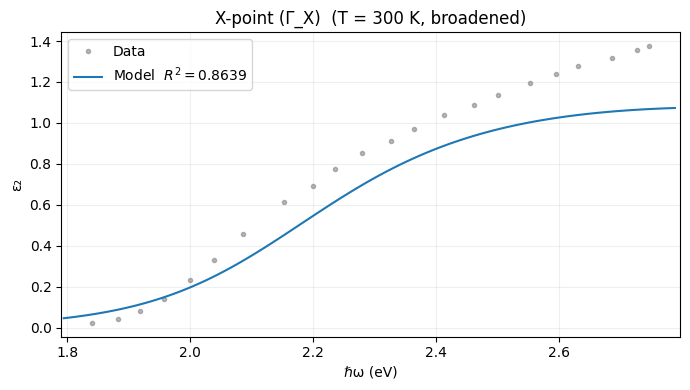


═══════════════════════════════════════════════════════
  X-point (Γ_X)                 R² = 0.8639
───────────────────────────────────────────────────────
  Eg_X           =   2.1258 eV
  mc_perp_X      =   0.3399 mₑ
  mc_par_X       =   0.6592 mₑ
  mv_perp_X      =   0.1021 mₑ
  mv_par_X       =   0.5859 mₑ
  P_ratio_sq     =   0.3747
  Scale          = 239.3808
  Gamma_X        =   0.0010 eV
═══════════════════════════════════════════════════════


In [10]:
keys_X_br = ['Eg_X', 'mc_perp_X', 'mc_par_X', 'mv_perp_X', 'mv_par_X',
             'P_ratio_sq', 'Scale', 'Gamma_X']
best_X_br = run_fit_broadened(data_X, 'X', keys_X_br, defaults_br)
e2_X_br = compute_model_broadened(best_X_br, hw_ext, hw)[0]
plot_panel_br(data_X, e2_X_br, "X-point (Γ_X)", best_X_br, keys_X_br)

### Broadened Fit 2 — L-point

**8 free parameters:** $E_g^L$, $E_{0c}^L$, 4 L-masses, Scale, $\Gamma_L$. &ensp; $T = 300\,$K fixed.

DE (Γ):   0%|          | 0/150 [00:00<?, ?it/s]

  DE  cost = 0.0978
  TRF cost = 0.0025  (192 evals)


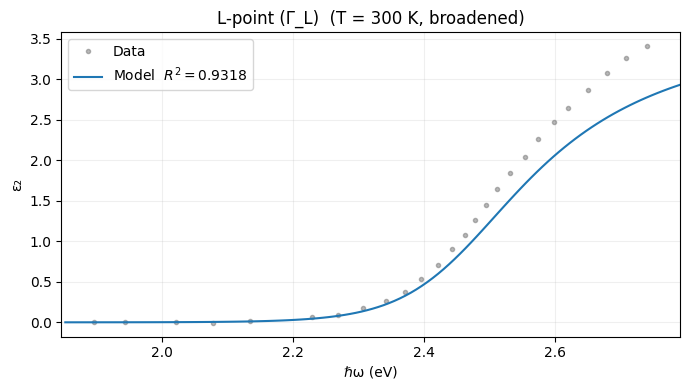


═══════════════════════════════════════════════════════
  L-point (Γ_L)                 R² = 0.9318
───────────────────────────────────────────────────────
  Eg_L           =   1.8170 eV
  E0c_L          =  -0.2632 eV
  mc_perp_L      =   0.2644 mₑ
  mc_par_L       =   0.1339 mₑ
  mv_perp_L      =   0.1861 mₑ
  mv_par_L       =   0.1589 mₑ
  Scale          = 296.5538
  Gamma_L        =   0.0010 eV
═══════════════════════════════════════════════════════


In [11]:
keys_L_br = ['Eg_L', 'E0c_L', 'mc_perp_L', 'mc_par_L', 'mv_perp_L', 'mv_par_L',
             'Scale', 'Gamma_L']
best_L_br = run_fit_broadened(data_L, 'L', keys_L_br, defaults_br)
e2_L_br = compute_model_broadened(best_L_br, hw_ext, hw)[1]
plot_panel_br(data_L, e2_L_br, "L-point (Γ_L)", best_L_br, keys_L_br)

### Broadened Fit 3 — Combined interband (X + L)

**15 free parameters:** all band parameters, $|P_X/P_L|^2$, Scale, $\Gamma_X$, $\Gamma_L$. &ensp; $T = 300\,$K fixed.

DE (Γ):   0%|          | 0/200 [00:00<?, ?it/s]

  DE  cost = 0.1550
  TRF cost = 0.0032  (356 evals)


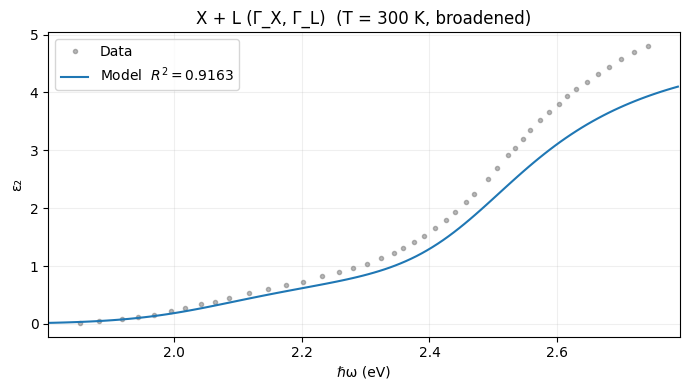


═══════════════════════════════════════════════════════
  X + L (Γ_X, Γ_L)              R² = 0.9163
───────────────────────────────────────────────────────
  Eg_X           =   2.0298 eV
  Eg_L           =   1.6145 eV
  E0c_L          =  -0.3364 eV
  mc_perp_X      =   0.7530 mₑ
  mc_par_X       =   1.2060 mₑ
  mv_perp_X      =   0.4466 mₑ
  mv_par_X       =   0.9459 mₑ
  mc_perp_L      =   1.2664 mₑ
  mc_par_L       =   0.2381 mₑ
  mv_perp_L      =   0.8402 mₑ
  mv_par_L       =   1.6487 mₑ
  P_ratio_sq     =   0.2345
  Scale          =  46.1886
  Gamma_X        =   0.0010 eV
  Gamma_L        =   0.0010 eV
═══════════════════════════════════════════════════════


In [12]:
keys_XL_br = ['Eg_X', 'Eg_L', 'E0c_L',
              'mc_perp_X', 'mc_par_X', 'mv_perp_X', 'mv_par_X',
              'mc_perp_L', 'mc_par_L', 'mv_perp_L', 'mv_par_L',
              'P_ratio_sq', 'Scale', 'Gamma_X', 'Gamma_L']
best_XL_br = run_fit_broadened(data_XL, 'XL', keys_XL_br, defaults_br, maxiter_de=200)
e2_XL_br = compute_model_broadened(best_XL_br, hw_ext, hw)[2]
plot_panel_br(data_XL, e2_XL_br, "X + L (Γ_X, Γ_L)", best_XL_br, keys_XL_br)

### Broadened Fit 4 — Full model (X + L + Drude)

**16 free parameters:** all band parameters, $\Gamma_X$, $\Gamma_L$, $A_D$. &ensp; $T = 300\,$K fixed.

DE (Γ):   0%|          | 0/200 [00:00<?, ?it/s]

  DE  cost = 2.2938
  TRF cost = 0.7928  (272 evals)


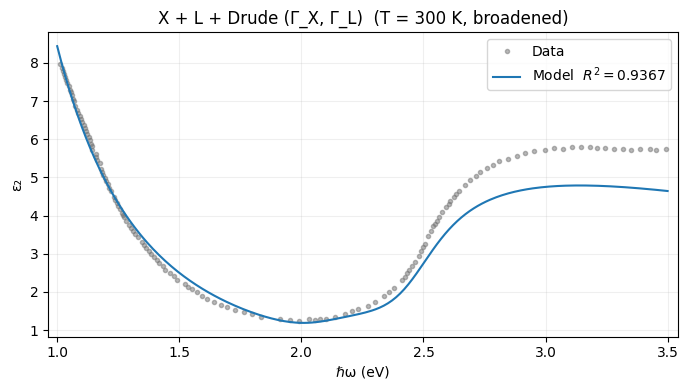


═══════════════════════════════════════════════════════
  X + L + Drude (Γ_X, Γ_L)      R² = 0.9367
───────────────────────────────────────────────────────
  Eg_X           =   2.0659 eV
  Eg_L           =   1.8325 eV
  E0c_L          =  -0.2518 eV
  mc_perp_X      =   0.3009 mₑ
  mc_par_X       =   0.6639 mₑ
  mv_perp_X      =   0.1815 mₑ
  mv_par_X       =   0.3229 mₑ
  mc_perp_L      =   0.3273 mₑ
  mc_par_L       =   0.5270 mₑ
  mv_perp_L      =   0.2241 mₑ
  mv_par_L       =   0.0505 mₑ
  P_ratio_sq     =   0.1427
  Scale          = 306.1750
  Gamma_X        =   0.0010 eV
  Gamma_L        =   0.0010 eV
  A_drude        =   8.4396 eV³
═══════════════════════════════════════════════════════


In [13]:
keys_XLD_br = ['Eg_X', 'Eg_L', 'E0c_L',
               'mc_perp_X', 'mc_par_X', 'mv_perp_X', 'mv_par_X',
               'mc_perp_L', 'mc_par_L', 'mv_perp_L', 'mv_par_L',
               'P_ratio_sq', 'Scale', 'Gamma_X', 'Gamma_L', 'A_drude']
best_XLD_br = run_fit_broadened(data_XLD, 'XLD', keys_XLD_br, defaults_br, maxiter_de=200)
e2_XLD_br = compute_model_broadened(best_XLD_br, hw_ext, hw)[3]
plot_panel_br(data_XLD, e2_XLD_br, "X + L + Drude (Γ_X, Γ_L)", best_XLD_br, keys_XLD_br)